<a href="https://colab.research.google.com/github/aabyyaann/UAS-ML/blob/main/Transaction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip install -q tensorflow optuna mlflow lime

In [33]:
import warnings
warnings.filterwarnings("ignore")

import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import optuna

import mlflow

from lime.lime_tabular import LimeTabularExplainer

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
DATA_PATH = "/content/drive/MyDrive/Midterm ML/train_transaction.csv"

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

print("Original Shape")
print(df.shape)

df = df.sample(
    n=100000,
    random_state=42
).reset_index(drop=True)

print("\nAfter Sampling")
print(df.shape)

Original Shape
(590540, 394)

After Sampling
(100000, 394)


In [36]:
print(df.head())

print("\nFraud Distribution")
print(df["isFraud"].value_counts())

   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        3457624        0       12153579         724.000         W   7826   
1        3552820        0       15005886         108.500         W  12544   
2        3271083        0        6970178          47.950         W   9400   
3        3226689        0        5673658         100.599         C  15885   
4        3268855        0        6886780         107.950         W  15497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0  481.0  150.0  mastercard  224.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  321.0  150.0        visa  226.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  111.0  150.0  mastercard  224.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  545.0  185.0        visa  138.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  490.0  150.0        visa  226.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   NaN   NaN  

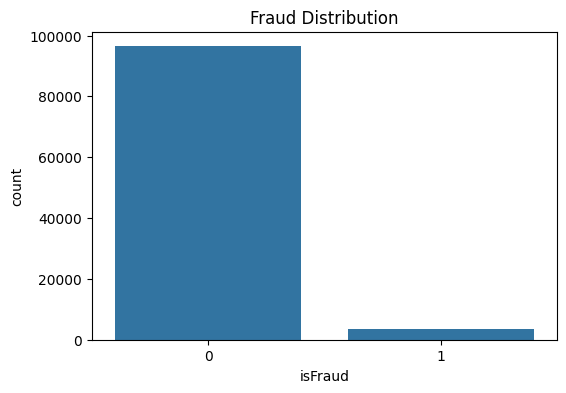

In [37]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["isFraud"]
)

plt.title("Fraud Distribution")

plt.show()

In [38]:
missing_percent = (
    df.isnull()
      .mean()
      .sort_values(ascending=False)
      *100
)

missing_percent.head(20)

,0
dist2,93.671
D7,93.359
D13,89.605
D14,89.480
D12,89.116
D6,87.664
D9,87.232
D8,87.232
V153,86.077
V140,86.077


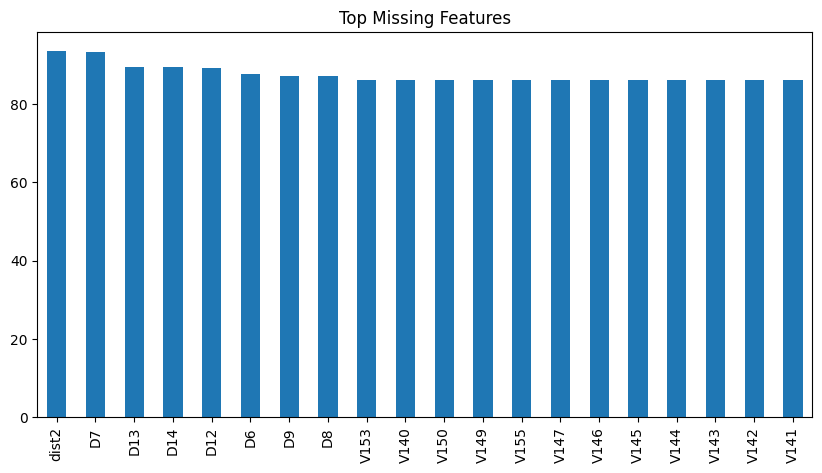

In [39]:
plt.figure(figsize=(10,5))

missing_percent.head(20).plot(
    kind="bar"
)

plt.title("Top Missing Features")

plt.show()

In [40]:
drop_cols = missing_percent[
    missing_percent > 85
].index

print("Dropped Columns")
print(len(drop_cols))

df.drop(
    columns=drop_cols,
    inplace=True
)

print(df.shape)

Dropped Columns
55
(100000, 339)


In [41]:
X = df.drop(
    columns=["isFraud"]
)

y = df["isFraud"]

if "TransactionID" in X.columns:
    X.drop(
        columns=["TransactionID"],
        inplace=True
    )

print(X.shape)

(100000, 337)


In [42]:
numeric_cols = X.select_dtypes(
    include=["int64","float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

print("Numeric :", len(numeric_cols))
print("Categorical :", len(categorical_cols))

Numeric : 323
Categorical : 14


In [43]:
num_imputer = SimpleImputer(
    strategy="median"
)

cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

X[numeric_cols] = num_imputer.fit_transform(
    X[numeric_cols]
)

X[categorical_cols] = cat_imputer.fit_transform(
    X[categorical_cols]
)

print(X.isnull().sum().sum())

0


In [44]:
encoders = {}

for col in categorical_cols:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    encoders[col] = le

In [45]:
del df
gc.collect()

7422

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [47]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(80000, 337)
(20000, 337)


In [48]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(
    zip(classes, weights)
)

class_weight_dict

{np.int64(0): np.float64(0.5185444457408056),
 np.int64(1): np.float64(13.981125480601188)}

In [49]:
baseline_model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

baseline_model.compile(

    optimizer="adam",

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

baseline_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │        43,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,097 (203.50 KB)

 Trainable params: 51,841 (202.50 KB)

 Non-trainable params: 256 (1.00 KB)

In [50]:
early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2
)

In [51]:
history = baseline_model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=8,

    batch_size=128,

    class_weight=class_weight_dict,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.7367 - auc: 0.7935 - loss: 0.5696 - val_accuracy: 0.7901 - val_auc: 0.8481 - val_loss: 0.4629 - learning_rate: 0.0010
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7642 - auc: 0.8393 - loss: 0.4955 - val_accuracy: 0.8372 - val_auc: 0.8565 - val_loss: 0.4450 - learning_rate: 0.0010
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7771 - auc: 0.8492 - loss: 0.4782 - val_accuracy: 0.8419 - val_auc: 0.8666 - val_loss: 0.3954 - learning_rate: 0.0010
Epoch 4/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7864 - auc: 0.8565 - loss: 0.4692 - val_accuracy: 0.7798 - val_auc: 0.8688 - val_loss: 0.4799 - learning_rate: 0.0010
Epoch 5/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7964 - auc: 0.8691 - loss: 0.4502 - val_accuracy: 0.8339 - val_auc: 0.8643 - val_loss: 0.3855 - learning_rate: 0.0010
Epoch 6/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8034 - auc: 0.8729 

In [52]:
y_prob = baseline_model.predict(
    X_test
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred
    )
)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     19285
           1       0.16      0.71      0.26       715

    accuracy                           0.85     20000
   macro avg       0.57      0.78      0.59     20000
weighted avg       0.96      0.85      0.89     20000



In [53]:
def objective(trial):

    units1 = trial.suggest_categorical(
        "units1",
        [64,128]
    )

    units2 = trial.suggest_categorical(
        "units2",
        [32,64]
    )

    dropout = trial.suggest_float(
        "dropout",
        0.1,
        0.3
    )

    lr = trial.suggest_float(
        "lr",
        1e-4,
        1e-3,
        log=True
    )

    model = Sequential([

        Input(shape=(X_train.shape[1],)),

        Dense(units1, activation="relu"),

        BatchNormalization(),

        Dropout(dropout),

        Dense(units2, activation="relu"),

        Dropout(dropout),

        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    history = model.fit(

        X_train,
        y_train,

        validation_split=0.2,

        epochs=3,

        batch_size=128,

        verbose=0
    )

    return max(
        history.history["val_auc"]
    )

In [54]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=5
)

best_params = study.best_params

print(best_params)

[I 2026-06-21 15:05:40,923] A new study created in memory with name: no-name-c677a80a-8b5e-40ef-9d0b-6711edace9f7
[I 2026-06-21 15:05:49,787] Trial 0 finished with value: 0.8581360578536987 and parameters: {'units1': 64, 'units2': 32, 'dropout': 0.29152291273058584, 'lr': 0.0009166779984569067}. Best is trial 0 with value: 0.8581360578536987.
[I 2026-06-21 15:06:01,705] Trial 1 finished with value: 0.8540664911270142 and parameters: {'units1': 128, 'units2': 64, 'dropout': 0.29973475169107267, 'lr': 0.0005962652083145378}. Best is trial 0 with value: 0.8581360578536987.
[I 2026-06-21 15:06:13,229] Trial 2 finished with value: 0.8437809944152832 and parameters: {'units1': 64, 'units2': 32, 'dropout': 0.2010469892025336, 'lr': 0.00020642412964417506}. Best is trial 0 with value: 0.8581360578536987.
[I 2026-06-21 15:06:25,234] Trial 3 finished with value: 0.8579630851745605 and parameters: {'units1': 64, 'units2': 32, 'dropout': 0.27189333876677313, 'lr': 0.0009618367065095024}. Best is t

{'units1': 64, 'units2': 32, 'dropout': 0.29152291273058584, 'lr': 0.0009166779984569067}


In [55]:
best_model = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(
        best_params["units1"],
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(
        best_params["dropout"]
    ),

    Dense(
        best_params["units2"],
        activation="relu"
    ),

    Dropout(
        best_params["dropout"]
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

best_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        best_params["lr"]
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [56]:
history_best = best_model.fit(

    X_train,
    y_train,

    validation_split=0.2,

    epochs=8,

    batch_size=128,

    class_weight=class_weight_dict,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7103 - auc: 0.7717 - loss: 0.5887 - val_accuracy: 0.7814 - val_auc: 0.8399 - val_loss: 0.4784 - learning_rate: 9.1668e-04
Epoch 2/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7525 - auc: 0.8262 - loss: 0.5107 - val_accuracy: 0.8051 - val_auc: 0.8507 - val_loss: 0.4286 - learning_rate: 9.1668e-04
Epoch 3/8
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7698 - auc: 0.8421 - loss: 0.4918 - val_accuracy: 0.8299 - val_auc: 0.8552 - val_loss: 0.4320 - learning_rate: 4.5834e-04


In [57]:
y_prob_best = best_model.predict(
    X_test
).ravel()

y_pred_best = (
    y_prob_best >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

roc_auc = roc_auc_score(
    y_test,
    y_prob_best
)

pr_auc = average_precision_score(
    y_test,
    y_prob_best
)

print("ROC AUC :", roc_auc)
print("PR AUC :", pr_auc)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.78      0.87     19285
           1       0.11      0.74      0.19       715

    accuracy                           0.78     20000
   macro avg       0.55      0.76      0.53     20000
weighted avg       0.96      0.78      0.85     20000

ROC AUC : 0.8444103990383482
PR AUC : 0.3533199454276324


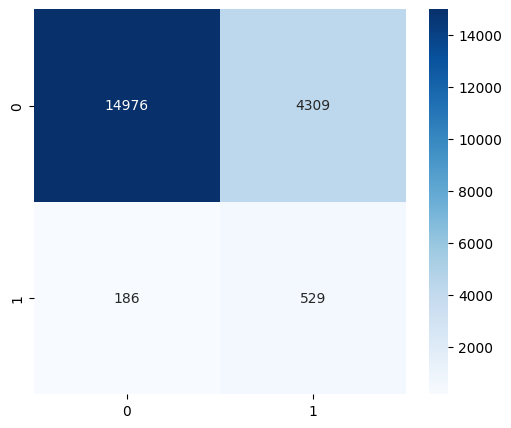

In [58]:
cm = confusion_matrix(
    y_test,
    y_pred_best
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.show()

In [59]:
mlflow.set_experiment(
    "Fraud Detection"
)

with mlflow.start_run():

    mlflow.log_params(
        best_params
    )

    mlflow.log_metric(
        "ROC_AUC",
        roc_auc
    )

    mlflow.log_metric(
        "PR_AUC",
        pr_auc
    )

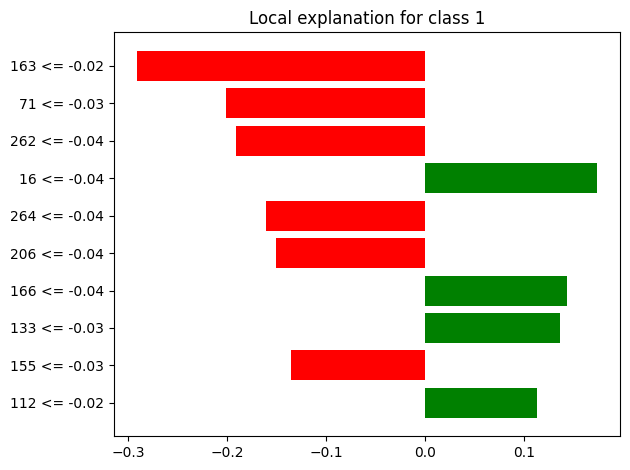

In [60]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train,
    mode="classification"
)

def predict_proba_lime(x):

    pred = best_model.predict(
        x,
        verbose=0
    )

    return np.hstack([
        1 - pred,
        pred
    ])

exp = explainer.explain_instance(
    X_test[0],
    predict_proba_lime,
    num_features=10
)

fig = exp.as_pyplot_figure()

plt.tight_layout()
plt.show()

In [61]:
best_model.save(
    "fraud_detection_model.keras"
)

print("Model Saved")

Model Saved
